# Parcial 2 IA

In [12]:
"""
Nombre: Jairo Blanco
Codigo: 2024114040
Materia: Inteligencia Artificial
Tema: Parcial 2 - Machine Learning and A*
"""

'\nNombre: Jairo Blanco\nCodigo: 2024114040\nMateria: Inteligencia Artificial\nTema: Parcial 2 - Machine Learning and A*\n'

# Parte 1

In [13]:
"""
1. B
2. C
3. B
4. B
5. B
"""

'\n1. B\n2. C\n3. B\n4. B\n5. B\n'

# Parte 2
SVM

In [14]:
#librerias necesarias
from sklearn import datasets # cargamos bases de datos
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC #support vector clasificator
from sklearn.metrics import accuracy_score
import numpy as np #librerias para calculos y matematicas
import matplotlib.pyplot as plt # libreria visual para nube de dispersion
from mlxtend.plotting import plot_decision_regions #libreria visual para grafica de fronteras de desicion

## A. Carga e inspección del conjunto de datos

In [11]:
data = datasets.load_breast_cancer()
X = data.data[:,[2,3]]
y = data.target

print(X.shape) #registros y los features asociados
print(np.bincount(y)) # registros por etiqueta
print(data.target_names) # nombre de las etiquetas

(569, 2)
[212 357]
['malignant' 'benign']


Vamos a visualizar la naturaleza de los datos

<function matplotlib.pyplot.show(close=None, block=None)>

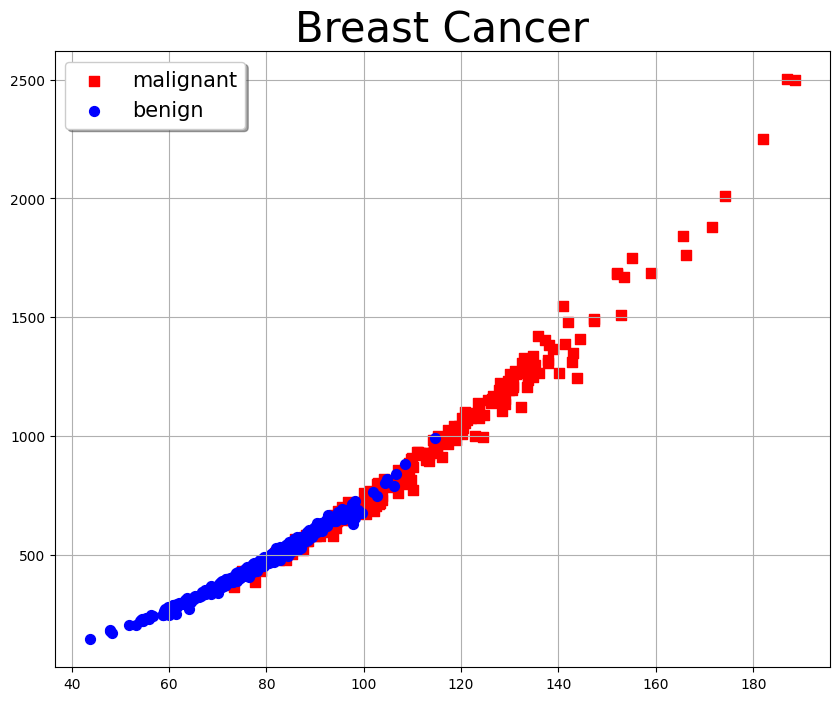

<function matplotlib.pyplot.show(close=None, block=None)>

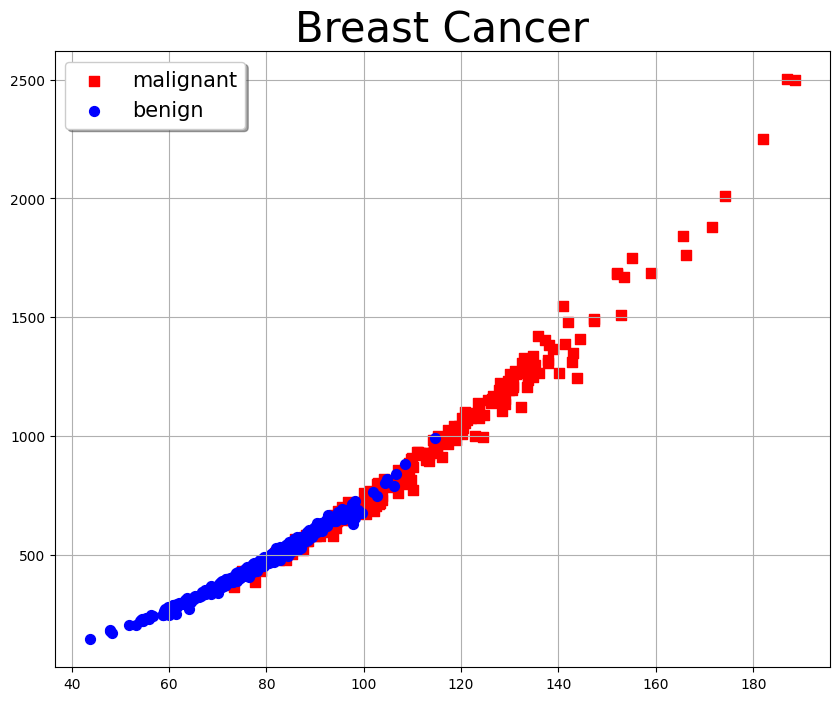

In [15]:
plt.figure(figsize=(10, 8))
plt.scatter(X[y==0,0],X[y==0,1],marker="s",color='red',s=50,label='malignant')
plt.scatter(X[y==1,0],X[y==1,1],marker="o",color='blue',s=50,label='benign')
plt.title('Breast Cancer', fontsize = 30)
plt.legend(loc='best', shadow = True, fontsize = 15)
plt.grid(True)
plt.show

# B. Partición de entrenamiento y prueba

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X , y, stratify=y, random_state= 42,train_size=0.7, test_size=0.3) #partimos de manera 70/30

# C. Estandarización

In [21]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

# D. SVM con kernel lineal



In [23]:
SVM1 = SVC(kernel='linear', C=1.0, random_state=42, max_iter= 1000)
SVM1.fit(X_train_std, y_train)

SVC(kernel='linear', max_iter=1000, random_state=42)

# E. SVM con kernel RBF

In [25]:
SVM2 = SVC(kernel='rbf', C=10.0, gamma="scale", random_state=42, max_iter= 1000)
SVM2.fit(X_train_std, y_train)

SVC(C=10.0, max_iter=1000, random_state=42)

Ahora vamos a la parte mas grafica

<function matplotlib.pyplot.show(close=None, block=None)>

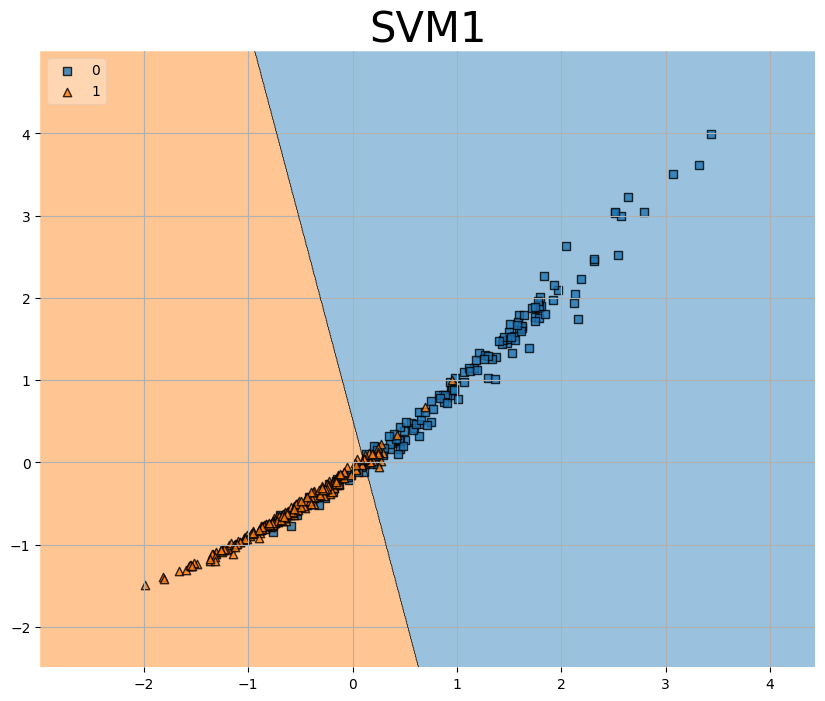

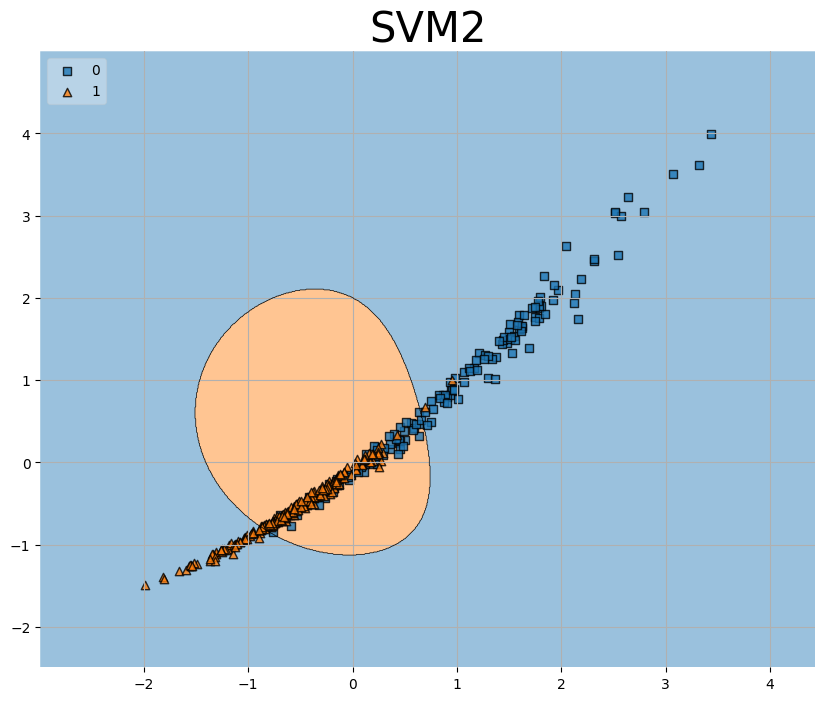

In [35]:
plt.figure(figsize=(10, 8))
plot_decision_regions(X_train_std, y_train, clf=SVM1, legend=2)
plt.title('SVM1', fontsize = 30)
plt.grid(True)
plt.show

plt.figure(figsize=(10, 8))
plot_decision_regions(X_train_std, y_train, clf=SVM2, legend=2)
plt.title('SVM2', fontsize = 30)
plt.grid(True)
plt.show

# F. Comparación técnica e interpretación

Generamos un dataframe de tipo tabla comparativa

In [40]:
dataframe = []
dataframe.append({
    "Modelo": "SVM1",
    "C":1.0,
    "gamma": "-",
    "Kernel": "linear",
    "test_accuracy": accuracy_score(y_test, SVM1.predict(X_test_std)),
    "train_accuracy": accuracy_score(y_train, SVM1.predict(X_train_std))
})
dataframe.append({
    "Modelo": "SVM2",
    "C":10.0,
    "gamma":"scale",
    "Kernel": "rbf",
    "test_accuracy": accuracy_score(y_test, SVM2.predict(X_test_std)),
    "train_accuracy": accuracy_score(y_train, SVM2.predict(X_train_std))
})
df = pd.DataFrame(dataframe)
df

,Modelo,C,gamma,Kernel,test_accuracy,train_accuracy
0,SVM1,1.0,-,linear,0.853801,0.879397
1,SVM2,10.0,scale,rbf,0.678363,0.693467


**Conclusiones:** Observamos que para el dataset y su comportamiento el modelo que se ajusta un poco mas es el lineal, esta afirmación tambien se ve respaldada por el dataframe, en donde miramos que el accuracy es mucho mas alto en el kernel lineal, aunque se recomienda explorar otros modelos, ya que ninguno de los 2 llega al +95% de accuracy esperado.

# Parte III - Búsqueda informada: algoritmo A*
Considérese el grafo ponderado no dirigido mostrado en la figura. Se desea encontrar la ruta de menor costo
desde el nodo inicial A hasta el nodo objetivo J, aplicando manualmente la metodología del algoritmo A*.
Utilizar la función de evaluación f(n) = g(n) + h(n), donde g(n) corresponde al costo acumulado desde A hasta n,
h(n) a la estimación heurística desde n hasta J y f(n) al costo total estimado de la solución pasando por n.
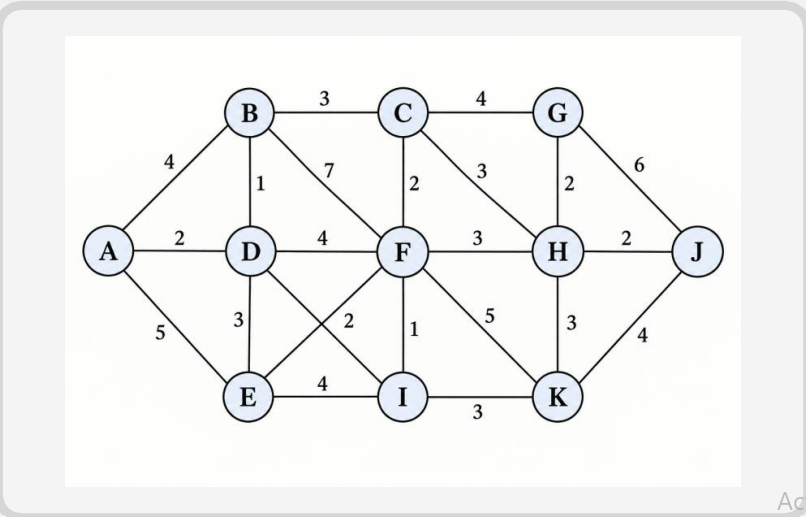

In [ ]:
grafo = {
    'A': [['B', 4], ['D', 2], ['D', 5]],
    'B': [['A', 4], ['D', 1], ['C', 3],['F', 7]],
    'C': [[]]
}
heuristica = {
    "A": 8,
    "B": 6,
    "C": 5,
    "D": 6,
    "E": 5,
    "F": 4,
    "G": 3,
    "H": 2,
    "I": 3,
    "J": 0,
    "K": 2
}